In [1]:
import os
import pandas as pd

In [2]:
vhh_file_path = "../data/humanization/abnativ_humanization/5m2jD_VHH_abnativ_seq_scores.csv"
vh_file_path = "../data/humanization/abnativ_humanization/5m2jD_VH_abnativ_seq_scores.csv"

vhh_df = pd.read_csv(
    vhh_file_path,
    usecols=['seq_id', 'AbNatiV VHH Score']
)
vh_df = pd.read_csv(
    vh_file_path,
    usecols=['seq_id', 'AbNatiV VH Score']
)

abnativ_df = pd.merge(vhh_df, vh_df, on='seq_id')
abnativ_df['group'] = abnativ_df['seq_id'].str.split('_').str[0]
abnativ_df['ID'] = abnativ_df['seq_id'].str.split('_').str[1:].str.join('_')

In [3]:
grafted_embedding_file_path = "../data/humanization/5m2jD_grafting_74A_94R_temp07_s50_250917/extract_distance/filter_best/grafted_raw_embeddings.tsv"

# grafted_embedding_file_path = "/data1/dhuang/Ig-fold/nanobody_db/humanization/5m2jD_grafting_74A_94R_temp07_s1000_250830/extract_distance_10/filter_avge/grafted_raw_embeddings.tsv"

original_embedding_file_path = "../data/humanization/5m2jD_grafting_74A_94R_temp07_s50_250917/extract_distance/filter_best/original_raw_embeddings.tsv"

grafted_df = pd.read_csv(grafted_embedding_file_path, sep='\t')
original_df = pd.read_csv(original_embedding_file_path, sep='\t')

In [4]:
# top_five_percent = int(0.05 * len(grafted_df))
# top_10_percent = int(0.1 * len(grafted_df))
# top_50_percent = int(0.5 * len(grafted_df))

# grafted_top_10_percent = int(0.1 * len(grafted_df))
grafted_top_100_percent = int(1 * len(grafted_df))
original_top_10_percent = int(0.1 * len(original_df))

top_grafted_df = pd.merge(grafted_df.iloc[:grafted_top_100_percent+1, :2], original_df.iloc[:original_top_10_percent+1, :2], on='PDB_ID')

In [5]:
top_grafted_df.head(5)

,PDB_ID,grafted_euclidean_all_raw_embeddings,original_euclidean_all_raw_embeddings
0,5m2jD_M99655_IGHV3-16_01_5M2J_CDR3_FR4_Q108L,20.177415,28.827923
1,5m2jD_MH332884_IGHV3-20_03_5M2J_CDR3_FR4_Q108L,21.435159,28.444387
2,5m2jD_MK540646_IGHV3-20_04_5M2J_CDR3_FR4_Q108L,21.644774,28.911771
3,5m2jD_M99657_IGHV3-20_01_5M2J_CDR3_FR4_Q108L,21.690882,29.923497
4,5m2jD_KC713939_IGHV3-13_05_5M2J_CDR3_FR4_Q108L,21.821124,29.787040


In [ ]:
# top_n = grafted_top_10_percent
# top_grafted_df = grafted_df.iloc[:top_n+1, :2]


In [5]:
top_grafted_abnativ_df = pd.merge(top_grafted_df, abnativ_df, how='inner', left_on='PDB_ID', right_on='ID')
top_grafted_abnativ_df['group'] = 'FANGS'
compare_abnativ_df = abnativ_df[abnativ_df['group'] != 'FANGS']

# compare_abnativ_df = abnativ_df.iloc[:2, :]
compare_abnativ_df.head(5)

,seq_id,AbNatiV VHH Score,AbNatiV VH Score,group,ID
0,Original_5m2jD,0.900171,0.830298,Original,5m2jD
1,TNF30_8z8mD,0.888101,0.849983,TNF30,8z8mD
2,HuDiff_VHv_nano_0,0.895698,0.879897,HuDiff,VHv_nano_0
3,HuDiff_VHv_nano_1,0.895838,0.890068,HuDiff,VHv_nano_1
4,HuDiff_VHv_nano_2,0.877496,0.885705,HuDiff,VHv_nano_2


To facilitate the interpretation of this score and the comparison of scores from the different trained models, the AbNatiV score is defined in such a way that it approaches 1 for highly native sequences and 0.8 represents the threshold that best separates native and non-native sequences

Non-gray fraction (AbNatiV VHH Score >= 0.8): 9/15 = 60.00%
  IGHV3-20_04 (*): 1 rows
  IGHV3-23_04 (D): 1 rows


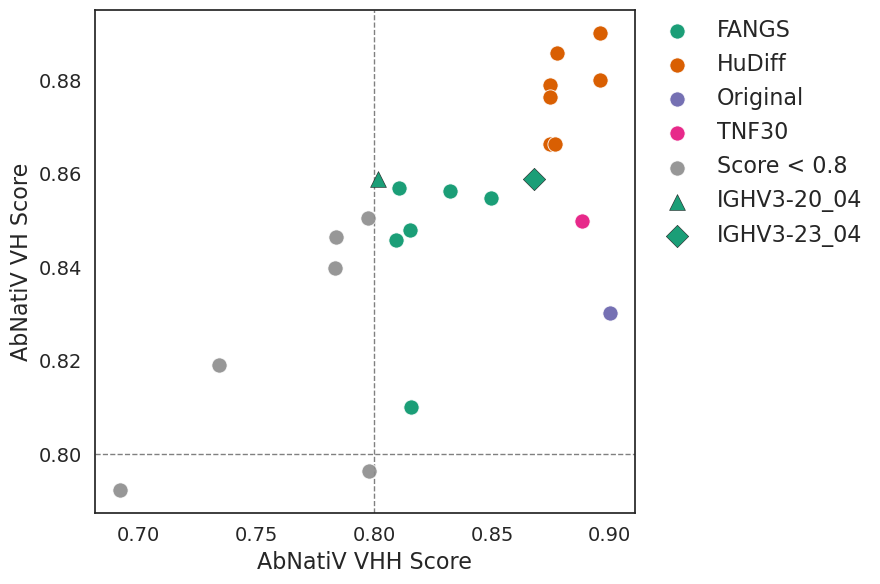

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from matplotlib.ticker import FormatStrFormatter

THRESH = 0.8

# 散点面积（points^2）：特殊点一般取普通点的 ~1.5–2.0 倍即可，过大再调小 S_MARK
S_BASE = 120
S_MARK = 130  # 原 320 过大；可试 110–160

def classify_ighv(row):
    parts = []
    for col in ("ID", "seq_id", "PDB_ID"):
        if col in row.index and pd.notna(row[col]):
            parts.append(str(row[col]))
    blob = " ".join(parts)
    if "IGHV3-20_04" in blob:
        return "IGHV3-20_04"
    if "IGHV3-23_04" in blob:
        return "IGHV3-23_04"
    return None

df = pd.concat([top_grafted_abnativ_df, compare_abnativ_df], ignore_index=True).copy()
df["below_thresh"] = df["AbNatiV VHH Score"] < THRESH
df["ighv_tag"] = df.apply(classify_ighv, axis=1)

fangs_df = df[df["group"] == "FANGS"]

n_total = len(fangs_df)
n_not_gray = int((~fangs_df["below_thresh"]).sum())
pct_not_gray = 100.0 * n_not_gray / n_total if n_total else 0.0
print(
    f"Non-gray fraction (AbNatiV VHH Score >= {THRESH}): "
    f"{n_not_gray}/{n_total} = {pct_not_gray:.2f}%"
)
for tag, mkr in [("IGHV3-20_04", "*"), ("IGHV3-23_04", "D")]:
    n = (df["ighv_tag"] == tag).sum()
    print(f"  {tag} ({mkr}): {n} rows")

sns.set(style="white")
groups = sorted(df["group"].dropna().unique())
palette = sns.color_palette("Dark2", n_colors=len(groups))
group_color = dict(zip(groups, palette))

fig, ax = plt.subplots(figsize=(9, 6))

# --- 非高亮：圆点 ---
for g, gdf in df[df["ighv_tag"].isna() & (~df["below_thresh"])].groupby("group"):
    ax.scatter(
        gdf["AbNatiV VHH Score"],
        gdf["AbNatiV VH Score"],
        color=group_color[g],
        s=S_BASE,
        marker="o",
        edgecolors="w",
        linewidths=0.6,
        label=str(g),
        zorder=2,
    )

sub = df[df["ighv_tag"].isna() & (df["below_thresh"])]
if len(sub):
    ax.scatter(
        sub["AbNatiV VHH Score"],
        sub["AbNatiV VH Score"],
        color="0.55",
        s=S_BASE,
        marker="o",
        edgecolors="w",
        linewidths=0.6,
        alpha=0.9,
        label=f"Score < {THRESH}",
        zorder=2,
    )

MARKER_20 = "^"
MARKER_23 = "D"

for tag, mkr in [("IGHV3-20_04", MARKER_20), ("IGHV3-23_04", MARKER_23)]:
    sub = df[(df["ighv_tag"] == tag) & (~df["below_thresh"])]
    if len(sub):
        fc = np.asarray([group_color[g] for g in sub["group"]])
        ax.scatter(
            sub["AbNatiV VHH Score"],
            sub["AbNatiV VH Score"],
            facecolors=fc,
            s=S_MARK,
            marker=mkr,
            edgecolors="k",
            linewidths=0.4,
            label=f"{tag}",
            zorder=4,
        )
    sub = df[(df["ighv_tag"] == tag) & (df["below_thresh"])]
    if len(sub):
        ax.scatter(
            sub["AbNatiV VHH Score"],
            sub["AbNatiV VH Score"],
            color="0.35",
            s=S_MARK,
            marker=mkr,
            edgecolors="k",
            linewidths=0.4,
            alpha=0.95,
            label=f"{tag}",
            zorder=4,
        )

ax.xaxis.set_major_formatter(FormatStrFormatter("%.2f"))
ax.yaxis.set_major_formatter(FormatStrFormatter("%.2f"))

x_min, x_max = ax.get_xlim()
y_min, y_max = ax.get_ylim()
ax.axvline(THRESH, linestyle="--", linewidth=1, color="gray", zorder=1)
ax.axhline(THRESH, linestyle="--", linewidth=1, color="gray", zorder=1)
ax.set_xlim(x_min, x_max)
ax.set_ylim(y_min, y_max)

ax.legend(
    title=None,
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    borderaxespad=0,
    frameon=False,
    fontsize=16,
)
ax.set_xlabel("AbNatiV VHH Score", fontsize=16)
ax.set_ylabel("AbNatiV VH Score", fontsize=16)
ax.tick_params(labelsize=14)
plt.tight_layout()

# --- 图像输出：先确保目录存在 ---
import os
save_path = "../figures/abnativ_vhh_vh_score_scatterplot.png"
os.makedirs(os.path.dirname(os.path.abspath(save_path)), exist_ok=True)
fig.savefig(save_path, dpi=600, bbox_inches="tight", facecolor="white")

plt.show()

### FANGS revision 20260831 standalone figure call
This cell reproduces the revised manuscript panel from the standalone script.


In [ ]:
from pathlib import Path
import subprocess
root = Path('/data1/dhuang/store/nanobody_db/final_version')
subprocess.run([
    '/data1/dhuang/miniconda3/envs/esm3/bin/python',
    '/data1/dhuang/store/nanobody_db/final_version/analysis/revision_20260831/plot_abnativ_comparison.py',
    '--vh', str(root / 'data/humanization/abnativ_humanization/5m2jD_VH_abnativ_seq_scores.csv'),
    '--vhh', str(root / 'data/humanization/abnativ_humanization/5m2jD_VHH_abnativ_seq_scores.csv'),
    '--top15', str(root / 'data/humanization/5m2jD_grafting_74A_94R_temp07_s50_250917/extract_distance/filter_best/top10pc_filtered_raw_embeddings.tsv'),
    '--output-dir', '/data1/dhuang/store/nanobody_db/final_version/figures/revision_20260831/main',
    '--n-resamples', '10000',
    '--seed', '20260831',
], check=True)
